# **Overview:**

## We are analyzing Reddit data to study the rise and recognition of slang terms, specifically comparing their usage trends to dictionary entry dates. Our dataset spans from 2010 to 2022.

# Link to dataset: https://huggingface.co/datasets/SocialGrep/the-reddit-dataset-dataset

## Installing requirements

In [ ]:
pip install datasets pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 12.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is 

## Loading and saving the dataset

In [ ]:
from datasets import load_dataset
import pandas as pd

# Load the 'comments' subset
dataset = load_dataset("SocialGrep/the-reddit-dataset-dataset", "comments", trust_remote_code=True)

# Convert to pandas DataFrame
df = dataset["train"].to_pandas()

# Save as CSV
df.to_csv("reddit_comments.csv", index=False)

print("Saved as reddit_comments.csv")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.92k [00:00<?, ?B/s]

the-reddit-dataset-dataset.py:   0%|          | 0.00/7.85k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/9.68M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/54848 [00:00<?, ? examples/s]

Saved as reddit_comments.csv


# Cleaning and formatting the data in our dataset (1/2)

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('reddit_comments.csv')

# Convert 'created_utc' to datetime
df['created_utc'] = pd.to_datetime(df['created_utc'])

# Show a preview
df.head()

,type,id,subreddit.id,subreddit.name,subreddit.nsfw,created_utc,permalink,body,sentiment,score
0,1,hyyz6g8,2r97t,datasets,False,2022-03-01 22:29:10+00:00,https://old.reddit.com/r/datasets/comments/t45...,Spatial problem: Suitability of new locations ...,0.0772,1
1,1,hyyid7v,2r97t,datasets,False,2022-03-01 20:41:20+00:00,https://old.reddit.com/r/datasets/comments/sg9...,Have you tried toying around with GDELT or Ali...,0.0000,2
2,1,hyxp1qp,2r97t,datasets,False,2022-03-01 17:33:38+00:00,https://old.reddit.com/r/datasets/comments/t44...,Damn random internet person of whom I know not...,-0.3851,3
3,1,hyxgnyu,2r97t,datasets,False,2022-03-01 16:39:42+00:00,https://old.reddit.com/r/datasets/comments/t44...,Ah nice one. Best of luck with the baby. If yo...,0.9136,3
4,1,hyxfjw6,2r97t,datasets,False,2022-03-01 16:32:25+00:00,https://old.reddit.com/r/datasets/comments/t49...,I was about to write and say this shouldn't be...,0.0762,2


# Cleaning and formatting the data in our dataset (2/2)

In [ ]:
from datetime import datetime

# Convert UTC timestamp to readable year
df['year'] = df['created_utc'].dt.year

# Lowercase and clean text
df['body'] = df['body'].astype(str).str.lower()

## Bag of Words approach using our list of slangs

In [ ]:
slang_terms = ['cap', 'sigma', 'yolo', 'lol', 'btw', 'lmao', 'karen', 'lit', 'bruh', 'bot']

# Initialize daily frequency dataframe
df['date'] = df['created_utc'].dt.date

daily_counts = pd.DataFrame(index=sorted(df['date'].unique()))

for term in slang_terms:
    daily_counts[term] = (
        df[df['body'].str.contains(fr'\b{term}\b', regex=True)]
        .groupby('date')
        .size()
    )

# Fill missing days with 0
daily_counts = daily_counts.fillna(0)

# Checking word frequency using iteration

In [ ]:
# Check how many times each slang term appears
for term in slang_terms:
    count = df['body'].str.contains(fr'\b{term}\b', regex=True).sum()
    print(f"'{term}': {count} matches")

'cap': 23 matches
'sigma': 9 matches
'yolo': 6 matches
'lol': 356 matches
'btw': 142 matches
'lmao': 33 matches
'karen': 5 matches
'lit': 5 matches
'bruh': 8 matches
'bot': 1222 matches


# Visualization: 30 Day Rolling Average of Slang Usage

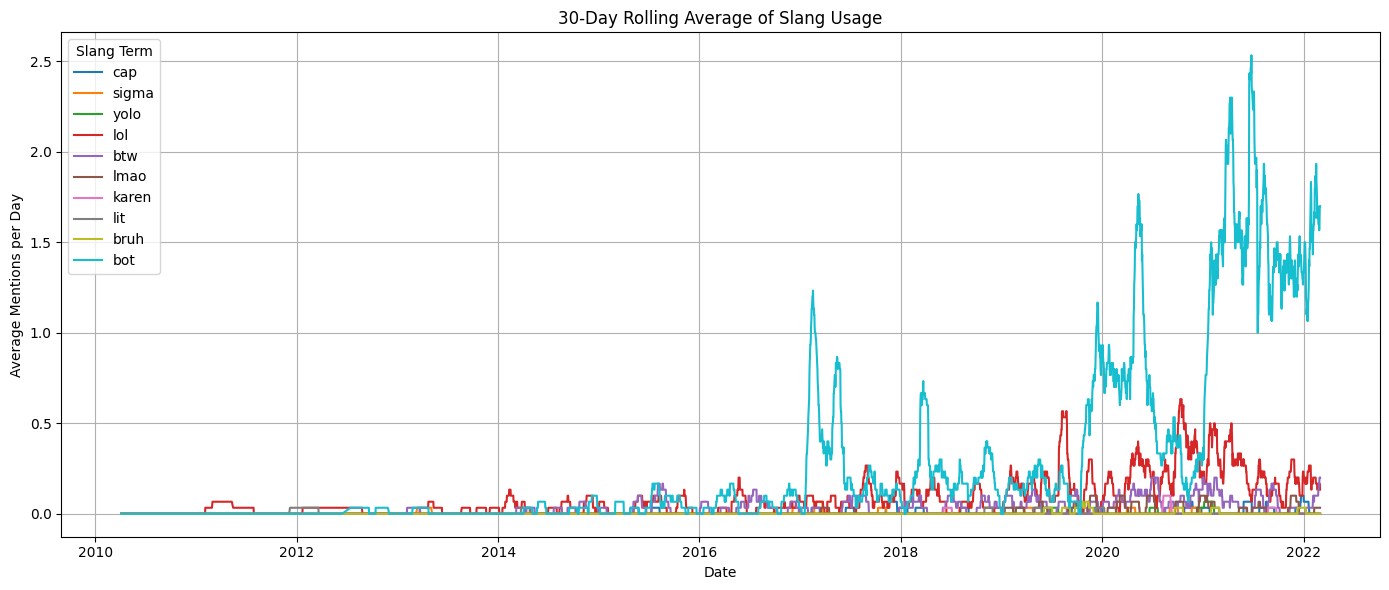

In [ ]:
rolling_counts = daily_counts.rolling(window=30, min_periods=1).mean()
rolling_counts.plot(figsize=(14, 6), title="30-Day Rolling Average of Slang Usage")
plt.xlabel("Date")
plt.ylabel("Average Mentions per Day")
plt.grid(True)
plt.legend(title="Slang Term")
plt.tight_layout()
plt.show()


# Visualization: Usage vs Dictionary Entry





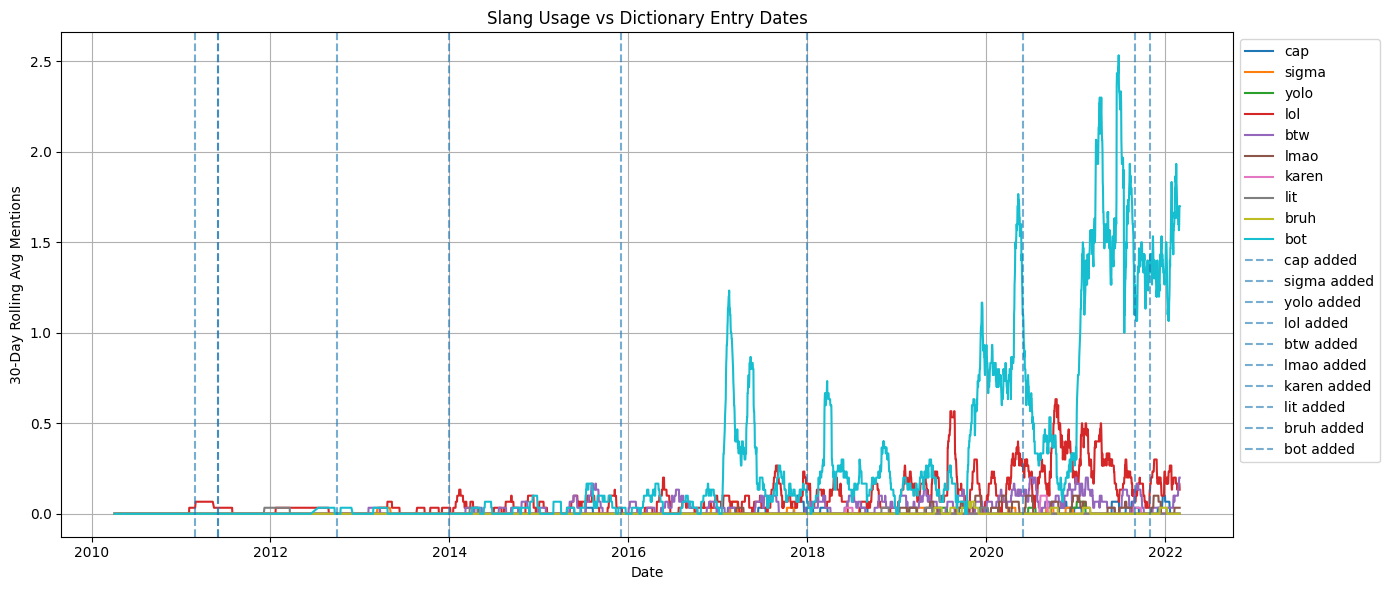

In [ ]:
# Updated dictionary-entry dates (based on public dictionary additions and internet slang timelines)
dictionary_dates = {
    'cap': '2021-09-01',        # Merriam-Webster added in 2021
    'sigma': '2021-11-01',      # Urban Dictionary spike; unofficial recognition
    'yolo': '2012-10-01',       # Added to Oxford Dictionary in 2012
    'lol': '2011-03-01',        # Added to Oxford English Dictionary (OED)
    'btw': '2011-06-01',        # Oxford Online, early 2010s
    'lmao': '2011-06-01',       # Added around the same time as “lol”
    'karen': '2020-06-01',      # Added to dictionary.com in 2020 (official slang use)
    'lit': '2015-12-01',        # Merriam-Webster & slang dictionaries, 2015
    'bruh': '2014-01-01',       # Urban Dictionary & meme culture, ~2014
    'bot': '2018-01-01',        # Oxford Dictionaries and gaming slang
}

plt.figure(figsize=(14, 6))
for term in slang_terms:
    plt.plot(rolling_counts.index, rolling_counts[term], label=term)

# Add dictionary entry lines
for term, date in dictionary_dates.items():
    plt.axvline(pd.to_datetime(date), linestyle='--', alpha=0.6, label=f"{term} added")

plt.xlabel("Date")
plt.ylabel("30-Day Rolling Avg Mentions")
plt.title("Slang Usage vs Dictionary Entry Dates")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # move legend out if it overlaps
plt.grid(True)
plt.tight_layout()
plt.show()
